The Nobel Prize has been among the most prestigious international awards since 1901. Each year, awards are bestowed in chemistry, literature, physics, physiology or medicine, economics, and peace. In addition to the honor, prestige, and substantial prize money, the recipient also gets a gold medal with an image of Alfred Nobel (1833 - 1896), who established the prize.

![](Nobel_Prize.png)

The Nobel Foundation has made a dataset available of all prize winners from the outset of the awards from 1901 to 2023. The dataset used in this project is from the Nobel Prize API and is available in the `nobel.csv` file in the `data` folder.

In this project, you'll get a chance to explore and answer several questions related to this prizewinning data. And we encourage you then to explore further questions that you're interested in!

In [19]:
# Loading in required libraries
import pandas as pd
import seaborn as sns
import numpy as np

# Start coding here!

In [20]:
# Load the Nobel Prize dataset
nobel = pd.read_csv('data/nobel.csv')

# Display the first few rows to verify successful loading
nobel.head()

,year,category,prize,motivation,prize_share,laureate_id,laureate_type,full_name,birth_date,birth_city,birth_country,sex,organization_name,organization_city,organization_country,death_date,death_city,death_country
0,1901,Chemistry,The Nobel Prize in Chemistry 1901,"""in recognition of the extraordinary services ...",1/1,160,Individual,Jacobus Henricus van 't Hoff,1852-08-30,Rotterdam,Netherlands,Male,Berlin University,Berlin,Germany,1911-03-01,Berlin,Germany
1,1901,Literature,The Nobel Prize in Literature 1901,"""in special recognition of his poetic composit...",1/1,569,Individual,Sully Prudhomme,1839-03-16,Paris,France,Male,NaN,NaN,NaN,1907-09-07,Châtenay,France
2,1901,Medicine,The Nobel Prize in Physiology or Medicine 1901,"""for his work on serum therapy, especially its...",1/1,293,Individual,Emil Adolf von Behring,1854-03-15,Hansdorf (Lawice),Prussia (Poland),Male,Marburg University,Marburg,Germany,1917-03-31,Marburg,Germany
3,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,462,Individual,Jean Henry Dunant,1828-05-08,Geneva,Switzerland,Male,NaN,NaN,NaN,1910-10-30,Heiden,Switzerland
4,1901,Peace,The Nobel Peace Prize 1901,NaN,1/2,463,Individual,Frédéric Passy,1822-05-20,Paris,France,Male,NaN,NaN,NaN,1912-06-12,Paris,France


In [21]:
# Find the most common gender and birth country
top_gender = nobel['sex'].value_counts().idxmax()
top_country = nobel['birth_country'].value_counts().idxmax()

print(f"Top Gender: {top_gender}")
print(f"Top Country: {top_country}")

Top Gender: Male
Top Country: United States of America


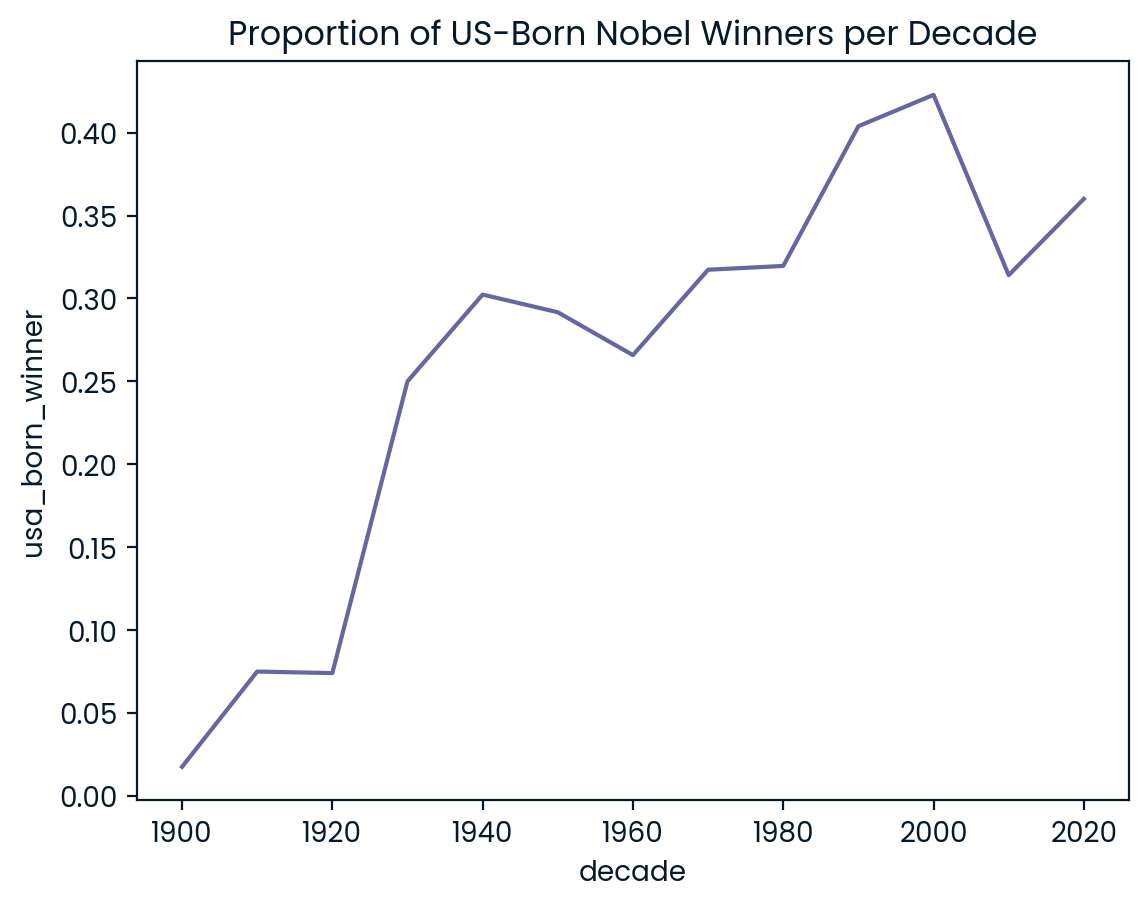

The decade with the highest ratio of US-born winners: 2000


In [22]:
# Import matplotlib.pyplot as plt
import matplotlib.pyplot as plt

# Create a USA-born flag and a decade column
nobel['usa_born_winner'] = nobel['birth_country'] == 'United States of America'
nobel['decade'] = (np.floor(nobel['year'] / 10) * 10).astype(int)

# Calculate the mean (proportion) per decade
prop_usa_winners = nobel.groupby('decade', as_index=False)['usa_born_winner'].mean()

# Visualize the trend
sns.lineplot(x='decade', y='usa_born_winner', data=prop_usa_winners)
plt.title("Proportion of US-Born Nobel Winners per Decade")
plt.show()

# We use idxmax() to find the index of the highest mean, then grab the 'decade' value
max_decade_usa = prop_usa_winners.loc[prop_usa_winners['usa_born_winner'].idxmax(), 'decade']

print(f"The decade with the highest ratio of US-born winners: {max_decade_usa}")

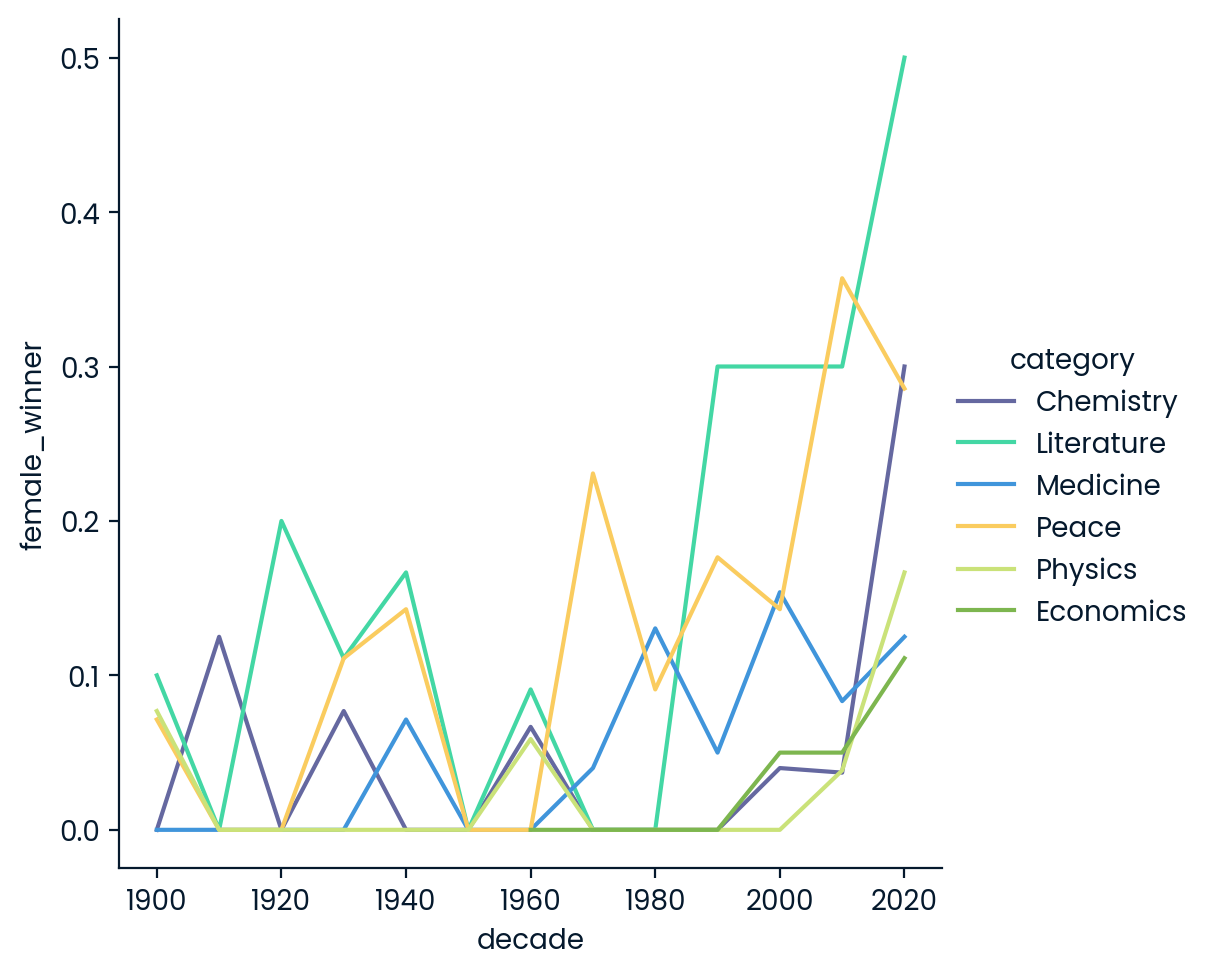

In [23]:
# Create a female winner flag
nobel['female_winner'] = nobel['sex'] == 'Female'

# Group by decade and category
prop_female_winners = nobel.groupby(['decade', 'category'], as_index=False)['female_winner'].mean()

# Find the maximum ratio
max_female_row = prop_female_winners.loc[prop_female_winners['female_winner'].idxmax()]
max_female_dict = {int(max_female_row['decade']): max_female_row['category']}

# Plotting the trend across categories
sns.relplot(x='decade', y='female_winner', hue='category', data=prop_female_winners, kind='line')
plt.show()

In [24]:
# First woman winner
nobel_women = nobel[nobel['sex'] == 'Female']
first_woman = nobel_women.nsmallest(1, 'year')
first_woman_name = first_woman['full_name'].values[0]
first_woman_category = first_woman['category'].values[0]

# Repeat winners (individuals or organizations)
counts = nobel['full_name'].value_counts()
repeat_list = list(counts[counts >= 2].index)

print(f"The first woman was {first_woman_name} in {first_woman_category}.")
print(f"Repeat winners: {repeat_list}")

The first woman was Marie Curie, née Sklodowska in Physics.
Repeat winners: ['Comité international de la Croix Rouge (International Committee of the Red Cross)', 'Linus Carl Pauling', 'John Bardeen', 'Frederick Sanger', 'Marie Curie, née Sklodowska', 'Office of the United Nations High Commissioner for Refugees (UNHCR)']
